# Классификация: превышение значением SI строго заданного порога

В данном ноутбуке решается задача бинарной классификации со строго заданным порогом: прогнозируется, является ли значение индекса селективности (SI) больше 8.

**Цель** - предсказать, превышает ли значение SI определенный порог.

## 1. Импорт библиотек и загрузка данных

In [7]:
# Импорт
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import re
from sklearn.metrics import precision_score, recall_score, f1_score


# Загрузка данных
df = pd.read_csv('cleaned_data.csv')
print("Размер датасета:", df.shape)

df.head()

Размер датасета: (1001, 78)


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,NumRadicalElectrons,...,fr_para_hydroxylation,fr_phos_acid,fr_phos_ester,fr_prisulfonamd,fr_pyridine,fr_sulfide,fr_sulfone,fr_term_acetylene,fr_thiocyan,fr_urea
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0,...,0,0,0,0,0,0,0,0,0,0
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0,...,0,0,0,0,0,0,0,0,0,0
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0,...,0,0,0,0,0,0,0,0,0,0
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0,...,0,0,0,0,0,0,0,0,0,0
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Подготовка данных

Для классификации используется бинарный признак: превышает ли SI заданный порог 8

In [8]:
targets = ['IC50, mM', 'CC50, mM', 'SI']
X = df.drop(columns=targets, errors='ignore')
y_raw = df['SI']

# Создаем бинарный таргет
threshold = 8
y_bin = (y_raw > threshold).astype(int)

print(f'Заданный порог SI - {threshold}\n')

print('Пропорция распределения:')
y_bin.value_counts(normalize=True)

Заданный порог SI - 8

Пропорция распределения:


,proportion
SI,
0,0.643357
1,0.356643


- Распределение классов показывает умеренный дисбаланс: соединений класса 0 больше, чем соединений класса 1. Соотношение примерно 1к2

## 3. Разделение на train и test

In [9]:
# Разделение на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

# Масштабирование
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def clean_column_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(col)) for col in df.columns]
    return df

X_train_scaled = clean_column_names(X_train_scaled)
X_test_scaled = clean_column_names(X_test_scaled)

print(f"Размерность X_train: {X_train_scaled.shape}")

Размерность X_train: (800, 75)


## 4. Обучение моделей
Для решения задачи сравним несколько типов моделей:

- логистическую регрессию
- метод ближайших соседей
- решающее дерево
- ансамбли деревьев
- бустинговые модели

Это позволит понять, какие алгоритмы лучше подходят для разделения соединений по уровню SI.

In [10]:
# Базовое сравнение моделей (без настройки)
models = {
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1, force_col_wise=True, n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # predict_proba есть не у всех моделей
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = None
        roc = 0.0

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({'Model': name, 'Precision': precision, 'Recall': recall,'F1': f1, 'ROC-AUC': roc})

res_df = pd.DataFrame(results).sort_values(by='F1', ascending=False)
print("\nСравнение моделей без настройки:")
display(res_df)


Сравнение моделей без настройки:


,Model,Precision,Recall,F1,ROC-AUC
0,KNN,0.594203,0.569444,0.581560,0.701281
3,RandomForest,0.622951,0.527778,0.571429,0.727444
2,LogisticRegression,0.582090,0.541667,0.561151,0.683947
7,LightGBM,0.593750,0.527778,0.558824,0.723353
4,ExtraTrees,0.587302,0.513889,0.548148,0.711779
5,XGBoost,0.567164,0.527778,0.546763,0.718508
6,GradientBoosting,0.580645,0.500000,0.537313,0.716731
1,DecisionTree,0.486486,0.500000,0.493151,0.602606


- Наилучший результат по F1 показали `RandomForesClassifier` и `KNeighborsClassifier`.

- Что интересно, KNN определяет несколько лучше объекты по recall, нежели RandomForest (57% против 53%)

- В целом качество моделей можно считать умеренным. Это связано с тем, что задача SI > 8 сложнее классификации относительно медианы: положительный класс встречается реже.

Выполним подбор гиперпараметров для наиболее перспективных алгоритмов. В качестве основной метрики используется `F1`, так как она учитывает баланс между `precision` и `recall`.

## 5. Подбор гиперпараметров

### RandomForest

In [11]:
# Настройка RandomForest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced', None]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_scaled, y_train)

best_rf_model = grid_rf.best_estimator_
print("\nЛучшие параметры RF:", grid_rf.best_params_)
print(f"Лучшая F1 на кросс-валидации: {grid_rf.best_score_:.4f}")

# Оценка на тесте
y_pred_rf = best_rf_model.predict(X_test_scaled)
y_prob_rf = best_rf_model.predict_proba(X_test_scaled)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"\nРезультаты RandomForest на тесте:")
print(f"F1-score: {f1_rf:.4f}")
print(f"ROC-AUC:  {roc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Fitting 3 folds for each of 48 candidates, totalling 144 fits

Лучшие параметры RF: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Лучшая F1 на кросс-валидации: 0.5886

Результаты RandomForest на тесте:
F1-score: 0.5674
ROC-AUC:  0.7256

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.78      0.77       129
           1       0.58      0.56      0.57        72

    accuracy                           0.70       201
   macro avg       0.67      0.67      0.67       201
weighted avg       0.69      0.70      0.70       201



- Модель работает стабильно (спад F1 с 0.5886 до 0.5674 на тесте незначителен).
- Проблема дисбаланса решена частично: параметр `class_weight='balanced'` помог улучшить прогноз для меньшинства, но класс 1 всё ещё предсказывается хуже.
- Основная слабость: низкая полнота (Recall) по классу 1 (56%). Модель часто пропускает объекты этого класса.
- **Общая оценка**: результат средний. Модель полезна, но есть потенциал для улучшения.

### KNeighborsClassifier

In [12]:
# Настройка KNN
knn_model = KNeighborsClassifier(
    n_jobs=-1,
    p=2
)

# Сетка параметров для KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid_knn,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(X_train_scaled, y_train)

best_knn_model = grid_knn.best_estimator_
print("\nЛучшие параметры KNN:", grid_knn.best_params_)
print(f"Лучшая F1 на кросс-валидации: {grid_knn.best_score_:.4f}")

# Оценка на тесте
y_pred_knn = best_knn_model.predict(X_test_scaled)
y_prob_knn = best_knn_model.predict_proba(X_test_scaled)[:, 1]

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_knn = roc_auc_score(y_test, y_prob_knn)

print(f"\nРезультаты KNN на тесте:")
print(f"F1-score: {f1_knn:.4f}")
print(f"ROC-AUC:  {roc_knn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Лучшие параметры KNN: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Лучшая F1 на кросс-валидации: 0.5879

Результаты KNN на тесте:
F1-score: 0.5931
ROC-AUC:  0.6946

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       129
           1       0.59      0.60      0.59        72

    accuracy                           0.71       201
   macro avg       0.68      0.68      0.68       201
weighted avg       0.71      0.71      0.71       201



- Модель стабильна: оценка на тесте (0.5931) близка к оценке кросс-валидации (0.5879).
- Проблема дисбаланса: класс 1 предсказывается хуже (Recall = 0.60), что типично для меньших классов.
- **Общая оценка**: результат посредственный. KNN с такими гиперпараметрами не является сильным классификатором для этой задачи.

## Выбираем лучшую модель

In [13]:
# Выбираем лучшую модель
if f1_knn>= f1_rf:
    best_final_model = best_knn_model
    best_final_name = "KNeighborsClassifier"
    y_pred_final = y_pred_knn
else:
    best_final_model = best_rf_model
    best_final_name = "RandomForestClassifier"
    y_pred_final = y_pred_rf

print(f'Лучшая модель - {best_final_name}')

Лучшая модель - KNeighborsClassifier


- После подбора гиперпараметров лучшей моделью стала KNeighborsClassifier.

## Матрица ошибок (Confusion Matrix) и ROC-кривая

Матрица ошибок показывает, сколько объектов каждого класса модель классифицировала правильно и неправильно

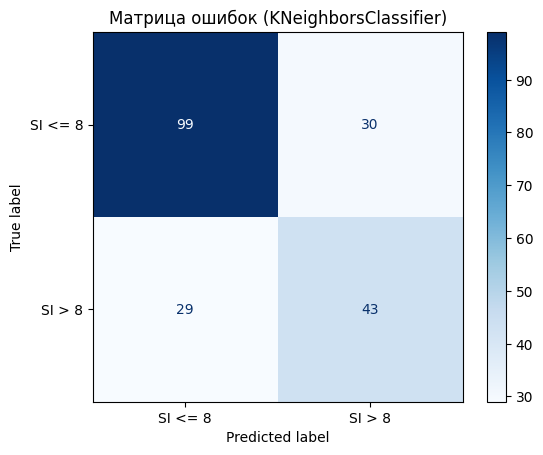

<Figure size 800x600 with 0 Axes>

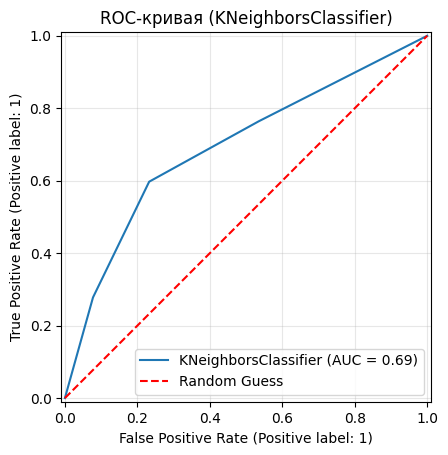

In [15]:
# Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["SI <= 8", "SI > 8"]
)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Матрица ошибок ({best_final_name})")
plt.grid(False)
plt.show()

# ROC-кривая
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(
    best_final_model,
    X_test_scaled,  # Важно: используем масштабированные данные!
    y_test,
    name=best_final_name
)
plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Random Guess")
plt.title(f"ROC-кривая ({best_final_name})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- Матрица ошибок показывает, что финальная модель лучше распознает класс SI <= 8, чем класс SI > 8.
- Модель правильно классифицировала 99 объектов класса 0(`SI <= 8`) и 43 объекта класса 1(`SI > 8`).

- Для положительного класса SI > 8 модель нашла 43 из 72, то есть recall составляет около 60%.

- ROC-кривая показывает, что финальная модель KNN разделяет классы лучше случайного классификатора (0,69>0.5). При этом качество разделения нельзя назвать высоким. Модель показывает умеренный результат: она способна находить часть соединений с SI > 8, но допускает заметное количество ошибок.

## Выводы

- Построена модель бинарной классификации для выявления соединений с показателем SI > 8.
- Из-за умеренного дисбаланса классов (64% против 36%) приоритет отдавался метрикам F1, recall, precision и ROC-AUC.
- Лучшим решением оказался алгоритм K-Nearest Neighbors с результатами на тесте: F1 = 0.59, ROC-AUC = 0.69.
- Модель демонстрирует явное смещение в пользу класса SI ≤ 8 (верно классифицировано 99 объектов против 43), но превосходит случайное угадывание.

- **Результат существенно лучше случайного угадывания.**